In [38]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split

In [39]:
file = "data/train.csv"
df = pd.read_csv(file, header=0)
df.head()

,user,item,rating
0,1,25715,7.0
1,1,25716,10.0
2,5,25851,9.0
3,6,25923,5.0
4,7,25924,6.0


In [40]:
df["rating"].min(), df["user"].unique().shape[0], df.shape

(np.float64(1.0), 73456, (390351, 3))

In [41]:
y = df["rating"]
x = df.drop(columns="rating")

In [42]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.1, random_state=42, stratify=df.rating)

In [43]:
x_train.shape, x_val.shape

((351315, 2), (39036, 2))

In [44]:
def create_sparse_matrix(x_train, y_train):
    # Map users and items to contiguous indices (0, 1, 2, ...)
    # This is necessary since your IDs are not sequential
    user_map = {u: i for i, u in enumerate(x_train['user'].unique())}
    item_map = {it: i for i, it in enumerate(x_train['item'].unique())}

    row = x_train['user'].map(user_map)
    col = x_train['item'].map(item_map)
    data = y_train.values

    sparse_matrix = csr_matrix(
        (data, (row, col)),
        shape=(len(user_map), len(item_map))
        ) 
    return sparse_matrix, user_map, item_map

In [ ]:
def compute_stats(sparse_matrix):
    csr = sparse_matrix.tocsr()
    csc = sparse_matrix.tocsc()

    user_sums   = np.array(csr.sum(axis=1)).flatten()
    user_counts = np.diff(csr.indptr)
    user_means  = np.where(user_counts > 0, user_sums / user_counts, np.nan)

    item_sums   = np.array(csc.sum(axis=0)).flatten()
    item_counts = np.diff(csc.indptr)
    item_means  = np.where(item_counts > 0, item_sums / item_counts, np.nan)

    global_mean = float(csr.data.mean()) if len(csr.data) > 0 else 0.0

    return user_means, item_means, global_mean


def get_user_distances_for_item(user_idx, item_idx, sparse_matrix, metrics, user_means):
    vec_a     = sparse_matrix[user_idx].toarray().flatten()
    nonzero_a = set(np.where(vec_a != 0)[0])
    mean_a    = user_means[user_idx]

    item_col          = sparse_matrix[:, item_idx].toarray().flatten()
    candidate_indices = np.where(
        (item_col != 0) & (np.arange(len(item_col)) != user_idx)
    )[0]

    if len(candidate_indices) == 0:
        return {m: np.array([]) for m in metrics}, np.array([]), np.array([])

    distances = {m: [] for m in metrics}
    ratings, valid_idx = [], []

    for j in candidate_indices:
        vec_b  = sparse_matrix[j].toarray().flatten()
        common = list(nonzero_a & set(np.where(vec_b != 0)[0]))
        if len(common) == 0:
            continue

        a, b   = vec_a[common], vec_b[common]
        mean_b = user_means[j]
        metric_results = {}

        if 'cosine' in metrics:
            norm = np.linalg.norm(a) * np.linalg.norm(b)
            metric_results['cosine'] = 1 - (np.dot(a, b) / norm) if norm > 0 else None

        if 'euclidean' in metrics:
            metric_results['euclidean'] = np.sqrt(np.sum((a - b) ** 2))

        if 'euclidean_bias' in metrics:
            if np.isnan(mean_a) or np.isnan(mean_b):
                metric_results['euclidean_bias'] = None
            else:
                metric_results['euclidean_bias'] = np.sqrt(
                    np.sum(((a - mean_a) - (b - mean_b)) ** 2)
                )

        if 'pearson' in metrics:
            if np.std(a) == 0 or np.std(b) == 0:
                metric_results['pearson'] = None
            else:
                metric_results['pearson'] = 1 - np.corrcoef(a, b)[0, 1]

        if 'jaccard_weighted' in metrics:
            denom = np.sum(np.maximum(a, b))
            if denom == 0:
                metric_results['jaccard_weighted'] = None
            else:
                w = 1 / (mean_a + 1e-8) if not np.isnan(mean_a) else 1.0
                metric_results['jaccard_weighted'] = 1 - w * (np.sum(np.minimum(a, b)) / denom)

        if any(v is None for v in metric_results.values()):
            continue

        for m in metrics:
            distances[m].append(metric_results[m])
        ratings.append(item_col[j])
        valid_idx.append(j)

    return (
        {m: np.array(distances[m]) for m in metrics},
        np.array(ratings),
        np.array(valid_idx)
    )


# ── Estrategias de cold-start disponibles ────────────────────────────────────
#
#   'item_mean'   → media del ítem
#   'user_mean'   → media del usuario
#   'global_mean' → media global
#   'const_X'     → valor constante X, donde X ∈ [1, 10]  (ej. 'const_5')
#   'range_1_10'  → shorthand para añadir const_1 … const_10 automáticamente
#
# Ejemplo de configuración:
#   cold_start = {
#       'unknown_user': ['item_mean', 'global_mean', 'range_1_10'],
#       'unknown_item': ['user_mean', 'global_mean', 'range_1_10'],
#       'both_unknown': ['global_mean', 'range_1_10'],
#   }
# ─────────────────────────────────────────────────────────────────────────────

def _expand_strategies(strats):
    """Expande 'range_1_10' en ['const_1', 'const_2', ..., 'const_10']."""
    expanded = []
    for s in strats:
        if s == 'range_1_10':
            expanded.extend([f'const_{v}' for v in range(1, 11)])
        else:
            expanded.append(s)
    return expanded


def evaluate_knn(x_val, y_val, sparse_matrix, user_map, item_map,
                 k_max=20, metrics=('cosine',), error_metric='rmse',
                 cold_start=None):
    if cold_start is None:
        cold_start = {
            'unknown_user' : ['item_mean', 'global_mean', 'range_1_10'],
            'unknown_item' : ['user_mean', 'global_mean', 'range_1_10'],
            'both_unknown' : ['global_mean', 'range_1_10'],
        }

    # Expandir range_1_10 en estrategias concretas
    cold_start = {case: _expand_strategies(strats) for case, strats in cold_start.items()}

    metrics  = list(metrics)
    k_values = list(range(2, k_max + 1))

    user_means, item_means, global_mean = compute_stats(sparse_matrix)

    val_df = x_val.copy()
    val_df['y_true'] = y_val.values
    val_df.columns   = ['user', 'item', 'y_true']

    knn_errors = {m: {k: [] for k in k_values} for m in metrics}
    cs_errors  = {
        case: {strat: [] for strat in strats}
        for case, strats in cold_start.items()
    }

    def _cold_pred(strat, user_idx=None, item_idx=None):
        if strat == 'item_mean':
            v = item_means[item_idx] if item_idx is not None else np.nan
        elif strat == 'user_mean':
            v = user_means[user_idx] if user_idx is not None else np.nan
        elif strat == 'global_mean':
            v = global_mean
        elif strat.startswith('const_'):
            v = float(strat.split('_')[1])
        else:
            v = np.nan
        return global_mean if (isinstance(v, float) and np.isnan(v)) else v

    def _err(pred, true):
        return (pred - true) ** 2 if error_metric == 'rmse' else abs(pred - true)

    for _, row in tqdm(val_df.iterrows(), total=len(val_df), desc="Evaluating"):
        user_id, item_id, y_true = row['user'], row['item'], row['y_true']

        user_known = user_id in user_map
        item_known = item_id in item_map

        # ── Cold start ────────────────────────────────────────────────────────
        if not user_known or not item_known:
            if not user_known and not item_known:
                case = 'both_unknown'
                for strat in cold_start.get(case, []):
                    cs_errors[case][strat].append(_err(_cold_pred(strat), y_true))

            elif not user_known:
                case     = 'unknown_user'
                item_idx = item_map[item_id]
                for strat in cold_start.get(case, []):
                    cs_errors[case][strat].append(
                        _err(_cold_pred(strat, item_idx=item_idx), y_true)
                    )
            else:
                case     = 'unknown_item'
                user_idx = user_map[user_id]
                for strat in cold_start.get(case, []):
                    cs_errors[case][strat].append(
                        _err(_cold_pred(strat, user_idx=user_idx), y_true)
                    )
            continue

        # ── KNN normal ───────────────────────────────────────────────────────
        user_idx = user_map[user_id]
        item_idx = item_map[item_id]

        dist_by_metric, ratings, _ = get_user_distances_for_item(
            user_idx, item_idx, sparse_matrix, metrics, user_means
        )

        if len(ratings) == 0:
            continue

        for m in metrics:
            distances = dist_by_metric[m]
            if len(distances) == 0:
                continue
            sorted_idx = np.argsort(distances)
            for k in k_values:
                k_actual = min(k, len(sorted_idx))
                top_idx  = sorted_idx[:k_actual]
                top_d    = distances[top_idx]
                top_r    = ratings[top_idx]
                weights  = 1 / (top_d + 1e-8)
                pred     = np.dot(weights, top_r) / weights.sum()
                knn_errors[m][k].append(_err(pred, y_true))

    def _agg(lst):
        if not lst:
            return np.nan
        return np.sqrt(np.mean(lst)) if error_metric == 'rmse' else np.mean(lst)

    knn_results = {
        m: (k_values, [_agg(knn_errors[m][k]) for k in k_values])
        for m in metrics
    }
    cs_results = {
        case: {strat: _agg(errs) for strat, errs in strats.items()}
        for case, strats in cs_errors.items()
    }

    return {'knn': knn_results, 'cold_start': cs_results}


def plot_knn_error(results, error_metric='rmse'):
    """
    Figura 1 : KNN error vs k (una línea por métrica)
    Figura 2+ : una figura por cada caso cold-start (unknown_user, unknown_item, both_unknown)
                con barras por estrategia, destacando el mejor
    """
    knn_results = results['knn']
    cs_results  = results['cold_start']

    knn_colors = ['steelblue', 'darkorange', 'seagreen', 'crimson', 'mediumpurple']
    best_ks    = {}

    # ── Figura 1: KNN error vs k ─────────────────────────────────────────────
    fig1, ax1 = plt.subplots(figsize=(13, 6))

    for i, (metric, (k_values, errors)) in enumerate(knn_results.items()):
        color  = knn_colors[i % len(knn_colors)]
        best_k = k_values[int(np.nanargmin(errors))]
        best_ks[metric] = best_k
        ax1.plot(k_values, errors, marker='o', linewidth=2, color=color,
                 label=f'{metric}  (best k={best_k}, {error_metric.upper()}={np.nanmin(errors):.4f})')
        ax1.axvline(best_k, color=color, linestyle='--', alpha=0.35)

    ax1.set_xlabel('k', fontsize=12)
    ax1.set_ylabel(error_metric.upper(), fontsize=12)
    ax1.set_title(f'KNN validation error vs k — {error_metric.upper()}',
                  fontsize=13, fontweight='bold')
    ax1.legend(fontsize=9, loc='best')
    ax1.grid(True, alpha=0.4)
    fig1.tight_layout()
    plt.show()

    # ── Figuras cold-start: una por caso ─────────────────────────────────────
    case_titles = {
        'unknown_user' : 'Cold-start: Usuario desconocido',
        'unknown_item' : 'Cold-start: Ítem desconocido',
        'both_unknown' : 'Cold-start: Usuario e Ítem desconocidos',
    }

    for case, strats in cs_results.items():
        valid = {s: e for s, e in strats.items() if not np.isnan(e)}
        if not valid:
            continue

        labels = list(valid.keys())
        values = list(valid.values())
        best_i = int(np.argmin(values))

        # Separar estrategias const de las demás para colorear diferente
        bar_colors = []
        for s in labels:
            if s.startswith('const_'):
                bar_colors.append('#5b9bd5')
            elif s in ('item_mean', 'user_mean'):
                bar_colors.append('#ed7d31')
            else:# mario estuvo aquí
                bar_colors.append('#a9a9a9')
        # Destacar el mejor en verde
        bar_colors[best_i] = '#70ad47'

        n      = len(labels)
        fig_w  = max(8, n * 0.7)
        fig, ax = plt.subplots(figsize=(fig_w, 5))

        bars = ax.bar(range(n), values, color=bar_colors, width=0.6, edgecolor='white')

        # Etiquetas eje X con rotación para que no se solapen
        ax.set_xticks(range(n))
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)

        ax.set_ylabel(error_metric.upper(), fontsize=12)
        ax.set_title(case_titles.get(case, case), fontsize=13, fontweight='bold')
        ax.grid(True, axis='y', alpha=0.4)

        y_offset = (max(values) - min(values)) * 0.015 + 0.001
        for idx, (bar, val) in enumerate(zip(bars, values)):
            weight = 'bold' if idx == best_i else 'normal'
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + y_offset,
                f'{val:.4f}',
                ha='center', va='bottom', fontsize=8, fontweight=weight
            )

        # Leyenda de colores
        from matplotlib.patches import Patch
        legend_handles = [
            Patch(color='#70ad47', label='Best strategy'),
            Patch(color='#5b9bd5', label='Constant (1–10)'),
            Patch(color='#ed7d31', label='Mean-based'),
            Patch(color='#a9a9a9', label='Global mean'),
        ]
        ax.legend(handles=legend_handles, fontsize=8, loc='upper right')
        ax.set_ylim(0, max(values) * 1.15)
        fig.tight_layout()
        plt.show()

    return best_ks

In [46]:
sparse_matrix, user_map, item_map = create_sparse_matrix(x_train, y_train)

In [ ]:
results = evaluate_knn(
    x_val, y_val, sparse_matrix, user_map, item_map,
    k_max=20,
    metrics=['cosine', 'euclidean', 'euclidean_bias', 'pearson', 'jaccard_weighted'],
    error_metric='rmse',
    cold_start={
        'unknown_user' : ['item_mean', 'global_mean', 'range_1_10'],
        'unknown_item' : ['user_mean', 'global_mean', 'range_1_10'],
        'both_unknown' : ['global_mean', 'range_1_10'],
    }
)

Evaluating: 100%|██████████| 39036/39036 [03:12<00:00, 202.82it/s]


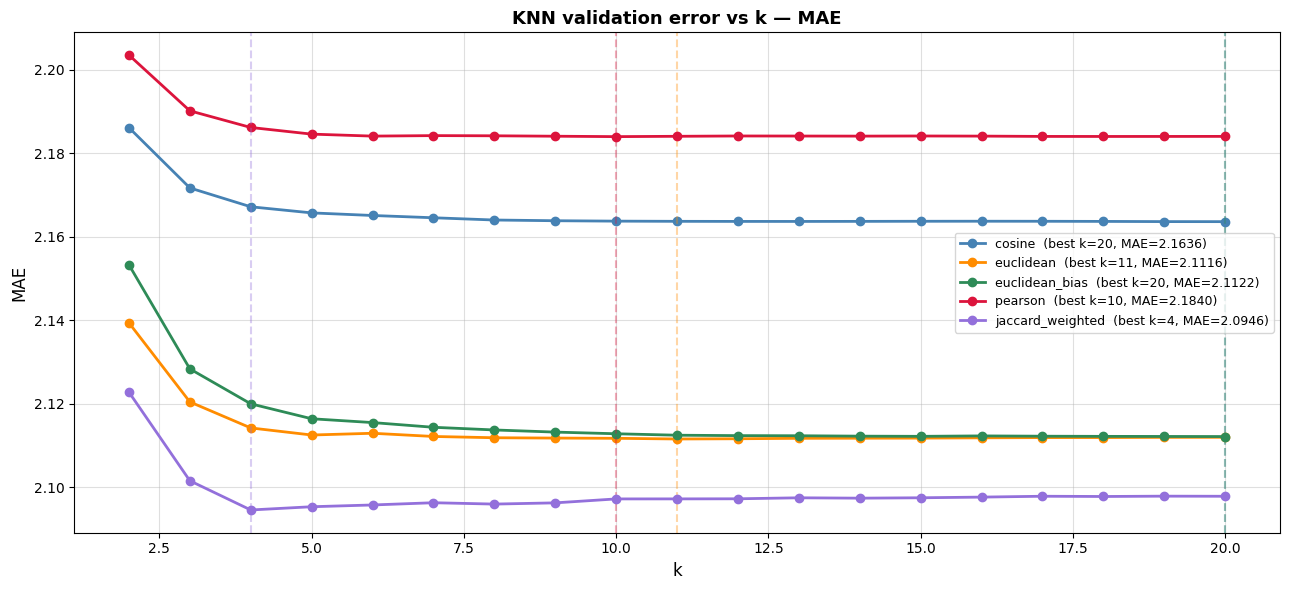

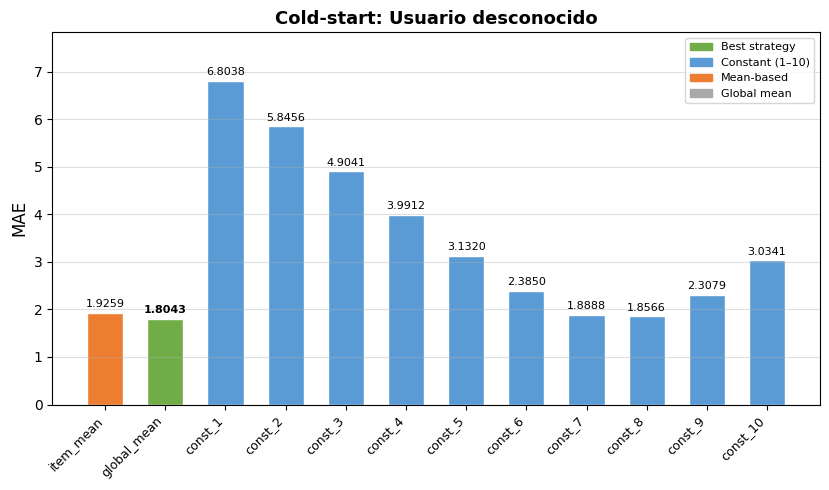

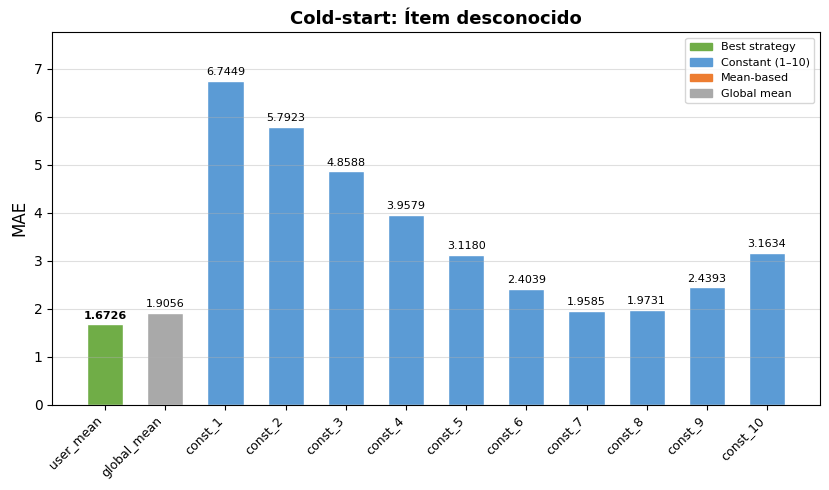

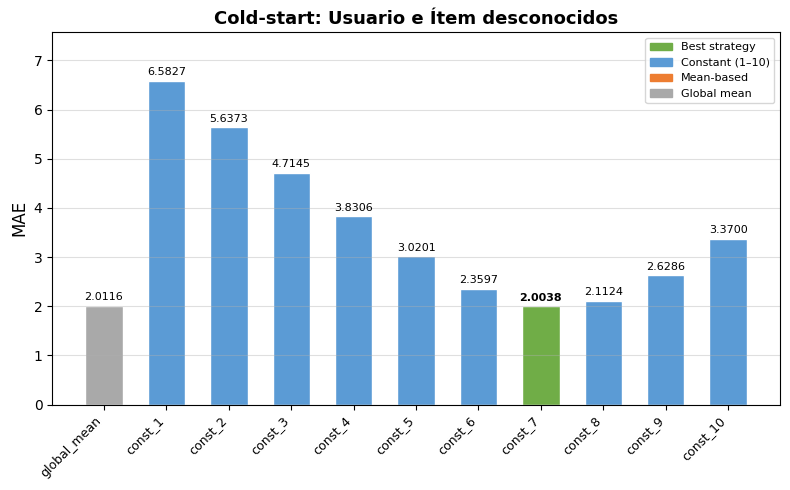

In [ ]:
best_ks = plot_knn_error(results, error_metric='mae') # AÑADIR DISTANCIA MANHATTAN

- Media del usuario cuando entra un ítem nuevo.
- 

# Test

In [ ]:
def predict(x_test, sparse_matrix, user_map, item_map,
            user_means, item_means, global_mean,
            metric='jaccard_weighted', k=5,
            cold_start_unknown_user='global_mean',
            cold_start_unknown_item='user_mean',
            cold_start_both='const_7'):
    """
    Genera predicciones para x_test usando los mejores parámetros encontrados.

    Parámetros
    ----------
    x_test                  : DataFrame con columnas [id, user, item]
    metric                  : métrica de distancia a usar (la mejor del evaluate_knn)
    k                       : número de vecinos (el mejor del evaluate_knn)
    cold_start_unknown_user : estrategia cuando el usuario no está en train
    cold_start_unknown_item : estrategia cuando el ítem no está en train
    cold_start_both         : estrategia cuando ninguno está en train

    Devuelve
    --------
    DataFrame con columnas [id, rating]
    """

    def _cold_pred(strat, user_idx=None, item_idx=None):
        if strat == 'item_mean':
            v = item_means[item_idx] if item_idx is not None else np.nan
        elif strat == 'user_mean':
            v = user_means[user_idx] if user_idx is not None else np.nan
        elif strat == 'global_mean':
            v = global_mean
        elif strat.startswith('const_'):
            v = float(strat.split('_')[1])
        else:
            v = np.nan
        return global_mean if (isinstance(v, float) and np.isnan(v)) else v

    ids   = []
    preds = []

    for _, row in tqdm(x_test.iterrows(), total=len(x_test), desc="Predicting"):
        row_id  = row.iloc[0]   # columna ID
        user_id = row.iloc[1]
        item_id = row.iloc[2]

        user_known = user_id in user_map
        item_known = item_id in item_map

        ids.append(row_id)

        # ── Cold start ────────────────────────────────────────────────────────
        if not user_known and not item_known:
            preds.append(_cold_pred(cold_start_both))
            continue

        if not user_known:
            item_idx = item_map[item_id]
            preds.append(_cold_pred(cold_start_unknown_user, item_idx=item_idx))
            continue

        if not item_known:
            user_idx = user_map[user_id]
            preds.append(_cold_pred(cold_start_unknown_item, user_idx=user_idx))
            continue

        # ── KNN normal ───────────────────────────────────────────────────────
        user_idx = user_map[user_id]
        item_idx = item_map[item_id]

        distances, ratings, _ = get_user_distances_for_item(
            user_idx, item_idx, sparse_matrix, [metric], user_means
        )
        distances = distances[metric]

        # Fallback si no hay vecinos con ítems en común
        if len(distances) == 0:
            preds.append(_cold_pred(cold_start_unknown_item, user_idx=user_idx))
            continue

        sorted_idx = np.argsort(distances)
        k_actual   = min(k, len(sorted_idx))
        top_idx    = sorted_idx[:k_actual]
        top_d      = distances[top_idx]
        top_r      = ratings[top_idx]
        weights    = 1 / (top_d + 1e-8)
        pred       = np.dot(weights, top_r) / weights.sum()

        preds.append(pred)

    return pd.DataFrame({'id': ids, 'rating': preds})

In [51]:
file_test = "data/test.csv"
df_test = pd.read_csv(file_test, header=0)
df_test.head()

,ID,user,item
0,0,8117,268
1,1,10512,24393
2,2,534,1334
3,3,10984,6550
4,4,9093,22128


In [53]:
sparse_matrix, user_map, item_map = create_sparse_matrix(df[["user", "item"]], df["rating"])

In [54]:
# Precomputar stats una sola vez (si no lo tienes ya)
user_means, item_means, global_mean = compute_stats(sparse_matrix)

predictions = predict(
    x_test         = df_test,           # DataFrame con [id, user, item]
    sparse_matrix  = sparse_matrix,
    user_map       = user_map,
    item_map       = item_map,
    user_means     = user_means,
    item_means     = item_means,
    global_mean    = global_mean,
    metric         = 'jaccard_weighted',
    k              = best_ks['jaccard_weighted'],  # del plot_knn_error
    cold_start_unknown_user = 'global_mean',
    cold_start_unknown_item = 'user_mean',
    cold_start_both         = 'const_7'
)

predictions.to_csv('submission.csv', index=False)

Predicting: 100%|██████████| 43320/43320 [02:51<00:00, 252.68it/s]


In [55]:
predictions.to_csv('submission.csv', index=False)

El flujo de decisión para cada fila es:
```
¿user en train? ──No──→ ¿item en train? ──No──→  const_7
                                └──Sí──→  global_mean (media del ítem)
       └──Sí──→ ¿item en train? ──No──→  user_mean
                       └──Sí──→  KNN con jaccard_weighted
                                  └── sin vecinos → user_mean (fallback)